# Deep Learning

Deep Learning is a branch of machine learning incentered on the study and the creaation of Deep Neural Networks (With more than two hidden layers) a special algorithm that can learn to solve almost any task
when given teoretically speaking a lot of data and computing power. Deep Learning is good when we have complex patterns but it struggles when :
- 🧠 **Data is scarce**: Deep models are data-hungry and prone to overfitting with small datasets.
- 🧮 **Interpretability is crucial**: Their internal workings are often opaque, making it hard to explain decisions.
- 🧪 **Domain knowledge matters**: In fields where expert-crafted features outperform learned ones, simpler models may be better.
- 🕰️ **Training time and resources are limited**: Deep networks require significant computational power and tuning.
- 📊 **Structured/tabular data dominates**: Traditional ML models like XGBoost or Random Forests often outperform deep nets on tabular datasets.

### Deep Learning Applications:

## 🖼️ Computer Vision
- **Examples:** object detection, face recognition, scene understanding.  
- **Common Applications:**  
  - Facial recognition systems  
  - Medical image diagnosis (e.g., tumor detection)  
  - Autonomous driving (lane detection, pedestrian recognition)

## 🗣️ Natural Language Processing (NLP)
- **Examples:** understanding, generating, or translating natural language text.  
- **Common Applications:**  
  - Chatbots and virtual assistants  
  - Machine translation (e.g., English ↔ Italian)  
  - Sentiment analysis for social media or reviews

## 🎨 Generative AI (Content Creation)
- **Examples:** generating images, text, music, or video.  
- **Common Applications:**  
  - AI image generation (art, design, prototyping)  
  - Writing assistants and code generation  
  - Speech synthesis and voice cloning

## 🎯 Recommendation Systems
- **Examples:** suggesting products, movies, or personalized content.  
- **Common Applications:**  
  - E-commerce product recommendations  
  - Streaming platforms (Netflix, Spotify)  
  - Social media content feeds

## 📈 Time Series Analysis
- **Examples:** predicting future values from past data.  
- **Common Applications:**  
  - Financial forecasting (stock prices, risk models)  
  - Weather prediction  
  - Energy demand management

Deep Learning tends to shine when the data has spatial or structured patterns that traditional models struggle to capture. By spatial, we usually mean data where local relationships and hierarchies matter — like pixels in an image, or even words in a sentence (which have sequential/spatial structure).

### The Neural Network:

A neural network (ANN) is a computational model inspired by the human brain. It is composed of elementary units called neurons, organized into layers that progressively transform input data into output.  
Layers of a neural network:
- Input layer: Receives input data (e.g., pixels, words, numbers).
- Hidden layers: A series of layers where transformations and learning occur.
- Output layer: Produces the result (e.g., class, value, probability).

### The perceprtron(Binary Linear classifier):

The perceptron was proposed by Frank Rosenblatt in 1958 as the first computational model inspired by the biological neuron. It is the simplest form of a neural network: a single layer of neurons that transforms inputs into a binary output.

#### ⚙️ How it Works

To train a perceptron, we need:

- 📊 **Training samples**: multiple input vectors. Each sample has several features, and the perceptron will create one weight for each feature.  
- 🏷️ **Labels vector**: one label for each sample, with values restricted to **0 or 1** (binary classification).  
- 🎚️ **Learning rate**: a parameter that controls how much the weights and bias are adjusted when the perceptron makes a mistake.  

### 🔮 Prediction

1. ➕ Compute a **weighted sum** of the inputs plus a bias:  
   `z = w*X + w2*X (for each weight and input vector) ... + b`  

2. ⚡ Apply a **step activation function**:  

pred_y = {1 if z>0  
    0 if z > 0  
}

3. 🎯 The output `pred_y` is the perceptron’s prediction.  

### 📚 Learning Process

During training, for each element in the dataset, the perceptron:

- 🔍 Computes a prediction as described above.  
- ✅ Compares the prediction with the true label.  
- 🔄 If the prediction is wrong, it updates its weights and bias according to the learning rule:  

1. `new_weight = current_weight + Learning rate * (True_Label - Pred_Label) * weight`  
2. `new_bias   = bias + Learning rate * (True_Label - Pred_Label)`  


✨ In short: the perceptron learns by **trial and error** — every time it misclassifies, it nudges its weights and bias in the right direction until it finds a decision boundary that separates the classes.

### 🚧 Perceptron: Learning Process and Its Limits

The perceptron was a groundbreaking idea in the late 1950s, but researchers soon discovered important **limitations** that restricted its usefulness.  
These limitations eventually led to the development of **multi‑layer neural networks** and the **backpropagation algorithm** (reintroduced in 1986 by Rumelhart, Hinton, and Williams), which overcame many of the perceptron’s weaknesses.


### ⚠️ Main Limitations of the Perceptron

1. **Linearity**  
   - The perceptron can only separate data that is **linearly separable**.  
   - If no straight line (or hyperplane in higher dimensions) can separate the classes, the perceptron will never converge.  
   - Example: the XOR problem cannot be solved by a single perceptron.

2. **No intermediate representations**  
   - A single perceptron cannot build **hierarchical or abstract features**.  
   - It only maps raw inputs directly to outputs, which is insufficient for complex tasks.

3. **Rigid activation function**  
   - The step function outputs only 0 or 1.  
   - This makes learning abrupt and prevents the model from expressing **gradual changes** or **uncertainty**.  
   - It also blocks the use of gradient‑based optimization methods.

4. **Limited learning capacity**  
   - The perceptron cannot model more complex logical relationships (like XOR).  
   - It is restricted to problems where a single linear boundary is enough.

### 🔑 Historical Impact

- Because of these limitations, research on perceptrons slowed down in the late 1960s and 1970s.  
- The revival came in the 1980s with the **rediscovery of backpropagation**, which allowed **multi‑layer perceptrons (MLPs)** to be trained efficiently.  
- By stacking perceptrons into layers and using differentiable activation functions (sigmoid, tanh, ReLU), neural networks gained the ability to learn **non‑linear decision boundaries** and **intermediate representations**.

- The **single‑layer perceptron** is powerful for understanding the foundations of machine learning but is limited to simple, linearly separable problems.  
- The **multi‑layer perceptron (MLP)**, trained with backpropagation, overcame these limits and became the cornerstone of modern deep learning.


# Binary Perceptron Implementation:

In [41]:
import numpy as np

class Perceptron:
    def __init__(self, input_datas, expected_datas, learning_rate=0.01, epochs=10):
        self.input_datas = np.array(input_datas)   # shape: (n_samples, n_features)
        self.labels = np.array(expected_datas)     # shape: (n_samples,)
        self.weights = np.zeros(self.input_datas.shape[1])  # one weight per feature
        self.bias = 0.0
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.errors_history = []

    def activation_function(self, x):
        return 1 if x >= 0 else 0

    def predict(self, input_data):
        z = np.dot(input_data, self.weights) + self.bias
        return self.activation_function(z)

    def fit(self):
        for epoch in range(self.epochs):
            errors = 0
            for x, target in zip(self.input_datas, self.labels):
                prediction = self.predict(x)
                error = target - prediction
                # Update rule
                self.weights += self.learning_rate * error * x
                self.bias += self.learning_rate * error
                errors += int(error != 0)
            self.errors_history.append(errors)
            print(f"Epoch {epoch+1}, Errors: {errors}, Weights: {self.weights}, Bias: {self.bias}")
            if errors == 0:
                print("Training complete: no errors left.")
                break
    
    def get_errors_history(self):
        return self.errors_history
    
    def get_epochs(self):
        return self.epochs
    
X = [[0,0],[0,1],[1,0],[1,1]]
y = [0,0,0,1]

p = Perceptron(X, y, learning_rate=0.1, epochs=10)
p.fit()

for sample in X:
    print(f"Input {sample} -> Prediction: {p.predict(sample)}")

Epoch 1, Errors: 2, Weights: [0.1 0.1], Bias: 0.0
Epoch 2, Errors: 3, Weights: [0.2 0.1], Bias: -0.1
Epoch 3, Errors: 3, Weights: [0.2 0.1], Bias: -0.20000000000000004
Epoch 4, Errors: 0, Weights: [0.2 0.1], Bias: -0.20000000000000004
Training complete: no errors left.
Input [0, 0] -> Prediction: 0
Input [0, 1] -> Prediction: 0
Input [1, 0] -> Prediction: 0
Input [1, 1] -> Prediction: 1


# Graphic Visualization

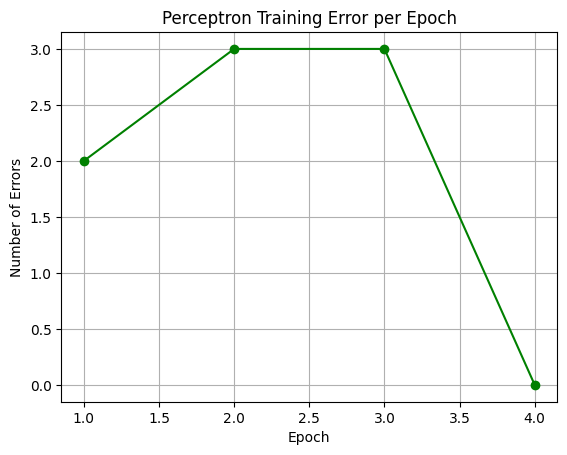

In [42]:
import matplotlib.pyplot as plt

# X-axis: epoch numbers
epochs = range(1, len(p.get_errors_history()) + 1)

# Y-axis: errors per epoch
plt.plot(epochs, p.get_errors_history(), 'g-o')

plt.title("Perceptron Training Error per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.grid(True)
plt.show()



### An Impossible (Non-Linear) example:


In [ ]:
# XOR dataset
X_xor = [[0,0],
         [0,1],
         [1,0],
         [1,1]]

y_xor = [0,1,1,0]

# Train perceptron
p_xor = Perceptron(X_xor, y_xor, learning_rate=0.1, epochs=20)
p_xor.fit()

epochs_xor = range(1, len(p_xor.get_errors_history()) + 1)

plt.plot(epochs_xor, p_xor.get_errors_history(), 'r-o')
plt.title("Perceptron Training Error per Epoch (XOR Problem)")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.show()


Epoch 1, Errors: 3, Weights: [-0.1  0. ], Bias: -0.1
Epoch 2, Errors: 3, Weights: [-0.1  0. ], Bias: 0.0
Epoch 3, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 4, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 5, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 6, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 7, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 8, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 9, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 10, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 11, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 12, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 13, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 14, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 15, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 16, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 17, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 18, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
Epoch 19, Errors: 4, Weights: [-0.1  0. ], Bias: 0.0
E